##Artificial Intelligence and Machine Learning in Space Exploration - Indian Space Academy

Project Title: Development of an AI-Based Real-Time Anamoly Detection using Autonomous Decision Support System for Deep Space Missions

####Phase 01 - Foundations

**Introduction to Spacecraft Systems**

A spacecraft system consists of several interconnected subsystems that work together to ensure the successful operation of a spacecraft in space. Each subsystem performs a specific function, and proper coordination among them is essential for mission success.

The power system is responsible for generating and supplying electrical energy to all onboard systems, typically using solar panels and batteries.
The thermal control system maintains the temperature of spacecraft components within safe limits despite extreme environmental conditions in space.
The communication system enables the transmission and reception of data between the spacecraft and ground stations on Earth.
The attitude and control system (ACS) ensures the spacecraft maintains the correct orientation and stability during its mission.
The propulsion system provides the necessary thrust for movement, orbit adjustments, and maneuvering.
The payload system contains mission-specific instruments such as cameras, sensors, or scientific equipment used to achieve mission objectives.
All these subsystems must function reliably in harsh space conditions such as vacuum, radiation, and extreme temperatures.

**What is Telemetry?**

Telemetry is the process of collecting data from sensors onboard a spacecraft and transmitting it to Earth for monitoring and analysis. It plays a crucial role in assessing the health and performance of the spacecraft throughout its mission.

Telemetry systems continuously monitor parameters such as temperature, pressure, voltage, current, and system status.
The collected data is processed and converted into a suitable format for transmission.
The data is transmitted using communication systems in the form of radio signals to ground stations.
Ground stations receive and decode the transmitted data for analysis by engineers and scientists.
Telemetry helps in detecting anomalies and diagnosing potential problems in real time.
It enables decision-making and corrective actions to ensure mission safety and reliability.
Without telemetry, it would be impossible to monitor or control a spacecraft effectively from Earth.

**Failure Modes in Spacecraft**

Failure modes refer to the various ways in which a spacecraft system or component can fail or stop functioning properly. Understanding these failure modes is essential for designing reliable and fault-tolerant spacecraft systems.

Electrical failures may occur due to power loss, battery degradation, or faults in circuits and wiring systems.
Mechanical failures involve malfunctioning of moving parts such as antennas, solar panels, or actuators that fail to deploy or operate correctly.
Thermal failures occur when components are exposed to temperatures beyond their operating limits, leading to overheating or freezing.
Communication failures result in loss or disruption of signal transmission between the spacecraft and Earth.
Software failures arise due to programming errors, bugs, or unexpected system behavior.
Sensor failures produce incorrect or unreliable data, which may lead to wrong system decisions.
Failure modes can lead to partial degradation or complete mission failure if not properly handled.
Identifying and analyzing failure modes helps in improving system design, reliability, and predictive maintenance strategies.

**DATASET:** NASA Turbofan Engine Degradation Dataset (CMAPSS)

In [1]:
from google.colab import files
uploaded = files.upload()

Saving CMAPSSData.zip to CMAPSSData.zip


In [2]:
import zipfile
import os

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/cmapss')

print("Files extracted:")
print(os.listdir('/content/cmapss'))

Files extracted:
['readme.txt', 'RUL_FD001.txt', 'test_FD003.txt', 'test_FD002.txt', 'test_FD004.txt', 'train_FD002.txt', 'train_FD001.txt', 'train_FD004.txt', 'train_FD003.txt', 'test_FD001.txt', 'RUL_FD003.txt', 'Damage Propagation Modeling.pdf', 'RUL_FD002.txt', 'RUL_FD004.txt']


In [3]:
import pandas as pd
import numpy as np

cols = ['unit','cycle'] + [f'op{i}' for i in range(1,4)] + [f's{i}' for i in range(1,22)]

train = pd.read_csv('/content/cmapss/train_FD001.txt', sep=r'\s+', header=None)
train.columns = cols

print("Shape:", train.shape)
train.head()

Shape: (20631, 26)


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
print(train.describe())

               unit         cycle           op1           op2      op3  \
count  20631.000000  20631.000000  20631.000000  20631.000000  20631.0   
mean      51.506568    108.807862     -0.000009      0.000002    100.0   
std       29.227633     68.880990      0.002187      0.000293      0.0   
min        1.000000      1.000000     -0.008700     -0.000600    100.0   
25%       26.000000     52.000000     -0.001500     -0.000200    100.0   
50%       52.000000    104.000000      0.000000      0.000000    100.0   
75%       77.000000    156.000000      0.001500      0.000300    100.0   
max      100.000000    362.000000      0.008700      0.000600    100.0   

                 s1            s2            s3            s4            s5  \
count  2.063100e+04  20631.000000  20631.000000  20631.000000  2.063100e+04   
mean   5.186700e+02    642.680934   1590.523119   1408.933782  1.462000e+01   
std    6.537152e-11      0.500053      6.131150      9.000605  3.394700e-12   
min    5.186700e+

Time series understanding

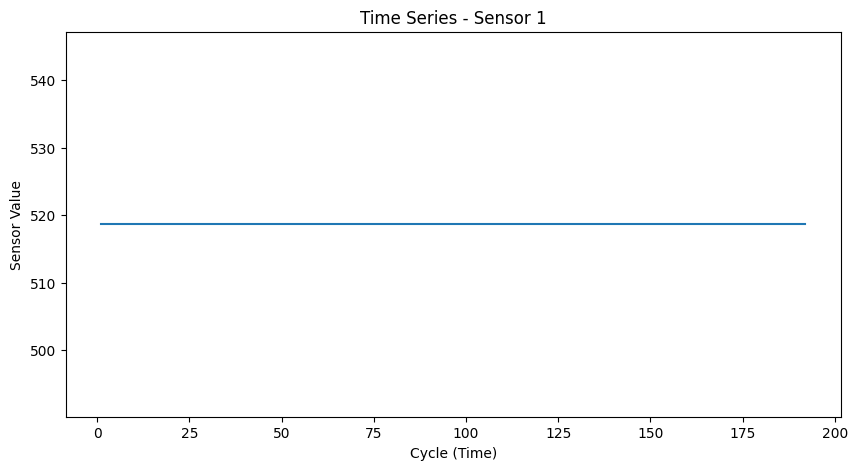

In [5]:
import matplotlib.pyplot as plt

unit_id = 1
unit_df = train[train['unit'] == unit_id]

plt.figure(figsize=(10,5))
plt.plot(unit_df['cycle'], unit_df['s1'])
plt.title("Time Series - Sensor 1")
plt.xlabel("Cycle (Time)")
plt.ylabel("Sensor Value")
plt.show()

Basic feature engineering

In [6]:
train['s1_rolling_mean'] = train.groupby('unit')['s1'].rolling(5).mean().reset_index(0,drop=True)

train = train.fillna(method='bfill')

train.head()

/tmp/ipykernel_3627/2600246742.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train = train.fillna(method='bfill')


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,s1_rolling_mean
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,518.67
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,518.67
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,518.67
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,518.67
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,518.67


Anomaly detection

In [7]:
from sklearn.ensemble import IsolationForest

# Select only sensor features
features = train.drop(['unit','cycle'], axis=1)

iso = IsolationForest(contamination=0.01, random_state=42)

train['anomaly'] = iso.fit_predict(features)

# -1 = anomaly, 1 = normal
train['anomaly'] = train['anomaly'].map({1:0, -1:1})

train['anomaly'].value_counts()

,count
anomaly,
0,20424
1,207


Visualize anomalies

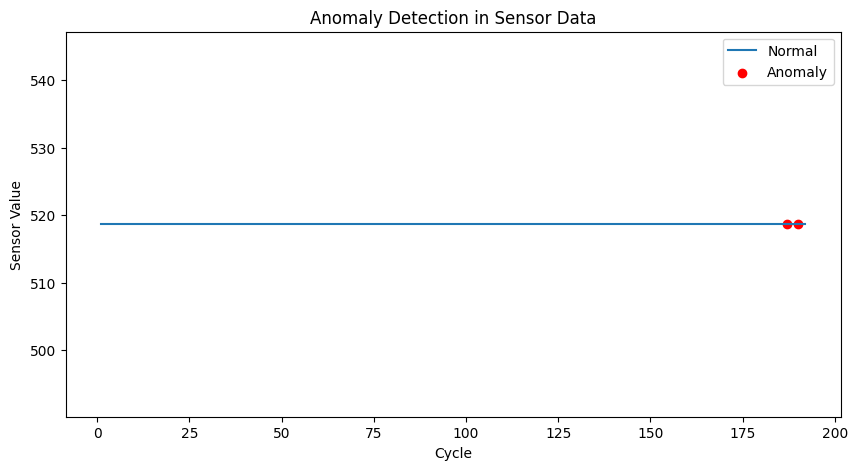

In [8]:
plt.figure(figsize=(10,5))

plt.plot(unit_df['cycle'], unit_df['s1'], label='Normal')

anomaly_points = train[(train['unit']==unit_id) & (train['anomaly']==1)]

plt.scatter(anomaly_points['cycle'], anomaly_points['s1'], color='red', label='Anomaly')

plt.legend()
plt.title("Anomaly Detection in Sensor Data")
plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.show()

Mini assignment

In [9]:
# Count anomalies per engine
anomaly_summary = train.groupby('unit')['anomaly'].sum()

print(anomaly_summary.sort_values(ascending=False).head())

unit
82    9
48    9
51    8
6     7
97    7
Name: anomaly, dtype: int64


One-class SVM — extra boost

In [10]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(nu=0.01)

svm_pred = svm.fit_predict(features)

train['svm_anomaly'] = [1 if x == -1 else 0 for x in svm_pred]

train['svm_anomaly'].value_counts()

,count
svm_anomaly,
0,20425
1,206


####Phase 02 - Model Development

Preprocess telemetry data

In [11]:
# Check missing
print(train.isnull().sum())

# Fill if any
train = train.fillna(method='ffill')
train = train.fillna(method='bfill')

unit               0
cycle              0
op1                0
op2                0
op3                0
s1                 0
s2                 0
s3                 0
s4                 0
s5                 0
s6                 0
s7                 0
s8                 0
s9                 0
s10                0
s11                0
s12                0
s13                0
s14                0
s15                0
s16                0
s17                0
s18                0
s19                0
s20                0
s21                0
s1_rolling_mean    0
anomaly            0
svm_anomaly        0
dtype: int64


/tmp/ipykernel_3627/194091495.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train = train.fillna(method='ffill')
/tmp/ipykernel_3627/194091495.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train = train.fillna(method='bfill')


In [12]:
# Remove extreme sensor values (simple clipping)
for col in train.columns:
    if col.startswith('s'):
        train[col] = train[col].clip(lower=train[col].quantile(0.01),
                                     upper=train[col].quantile(0.99))

Feature scaling

In [13]:
from sklearn.preprocessing import MinMaxScaler

features = train.drop(['unit','cycle','anomaly'], axis=1)

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)

Statistical baseline model

In [14]:
# Mean + std method
threshold = scaled_df.mean() + 3*scaled_df.std()

stat_anomaly = ((scaled_df > threshold).any(axis=1)).astype(int)

train['stat_anomaly'] = stat_anomaly

train['stat_anomaly'].value_counts()

,count
stat_anomaly,
0,19974
1,657


Ml anomaly detection model

In [15]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.02, random_state=42)

train['ml_anomaly'] = iso_model.fit_predict(scaled_df)
train['ml_anomaly'] = train['ml_anomaly'].map({1:0, -1:1})

train['ml_anomaly'].value_counts()

,count
ml_anomaly,
0,20218
1,413


Autoencoder (deep learning)

In [16]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = scaled_df.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)

decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train
autoencoder.fit(scaled_df, scaled_df,
                epochs=10,
                batch_size=64,
                validation_split=0.2)

Epoch 1/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0370 - val_loss: 0.0110
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0104 - val_loss: 0.0088
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0088 - val_loss: 0.0081
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0081 - val_loss: 0.0074
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0071 - val_loss: 0.0066
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0064 - val_loss: 0.0061
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0060 - val_loss: 0.0059
Epoch 8/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0058 - val_loss: 0.0056
Epoch 9/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0056 - val_loss: 0.0055
Epoch 10/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0054 - val_loss: 0.0054


In [17]:
reconstructions = autoencoder.predict(scaled_df)

mse = np.mean(np.power(scaled_df - reconstructions, 2), axis=1)

threshold = np.percentile(mse, 95)

train['ae_anomaly'] = (mse > threshold).astype(int)

train['ae_anomaly'].value_counts()

645/645 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


,count
ae_anomaly,
0,19599
1,1032


Rul prediction

In [20]:
# Create RUL
max_cycle_df = train.groupby('unit')['cycle'].max().reset_index()
# Rename the 'cycle_x' column in max_cycle_df to 'max_cycle' to avoid column collision and make it directly usable
max_cycle_df.rename(columns={'cycle': 'max_cycle'}, inplace=True)
train = train.merge(max_cycle_df, on='unit', how='left')

# Now 'train' will have its original 'cycle_x' column and the new 'max_cycle' column
train['RUL'] = train['max_cycle'] - train['cycle']
train = train.drop(columns=['max_cycle'])

Evaluation metrics

In [21]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(train['stat_anomaly'], train['ml_anomaly'])
print("ROC-AUC:", roc)

ROC-AUC: 0.6531636104104285


In [22]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(train['stat_anomaly'], train['ml_anomaly'])
recall = recall_score(train['stat_anomaly'], train['ml_anomaly'])

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.5036319612590799
Recall: 0.3165905631659056


In [23]:
false_alarms = ((train['ml_anomaly'] == 1) & (train['stat_anomaly'] == 0)).sum()
normal_points = (train['stat_anomaly'] == 0).sum()

far = false_alarms / normal_points

print("False Alarm Rate:", far)

False Alarm Rate: 0.010263342345048563


Visualize anomalies

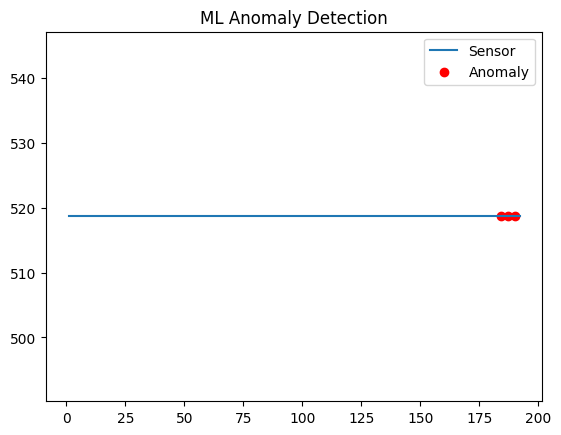

In [25]:
import matplotlib.pyplot as plt

unit_id = 1
unit_df = train[train['unit'] == unit_id]

plt.plot(unit_df['cycle'], unit_df['s1'], label='Sensor')

anomalies = unit_df[unit_df['ml_anomaly'] == 1]

plt.scatter(anomalies['cycle'], anomalies['s1'], color='red', label='Anomaly')

plt.legend()
plt.title("ML Anomaly Detection")
plt.show()

####Phase 03 - Autonomous Decision Layer

Rule-based decision system

In [26]:
def rule_based_decision(row):
    if row['ml_anomaly'] == 1:
        return "ALERT"
    else:
        return "NORMAL"

train['decision_rule'] = train.apply(rule_based_decision, axis=1)

train[['ml_anomaly','decision_rule']].head()

,ml_anomaly,decision_rule
0,0,NORMAL
1,0,NORMAL
2,0,NORMAL
3,0,NORMAL
4,0,NORMAL


In [27]:
def advanced_rule(row):
    if row['ae_anomaly'] == 1 and row['ml_anomaly'] == 1:
        return "CRITICAL"
    elif row['ml_anomaly'] == 1:
        return "WARNING"
    else:
        return "NORMAL"

train['decision_rule'] = train.apply(advanced_rule, axis=1)

AI-based decision

In [28]:
train['anomaly_score'] = (
    train['ml_anomaly'] * 0.5 +
    train['ae_anomaly'] * 0.5
)

Reinforcement logic

In [29]:
def reward_system(action):
    if action == "NORMAL":
        return 1
    elif action == "WARNING":
        return 0
    elif action == "CRITICAL":
        return -1

train['reward'] = train['decision_rule'].apply(reward_system)

Corrective action simulation

In [30]:
def corrective_action(decision):
    if decision == "CRITICAL":
        return "SHUT_DOWN_SUBSYSTEM"
    elif decision == "WARNING":
        return "SWITCH_TO_REDUNDANCY"
    else:
        return "NORMAL_OPERATION"

train['action'] = train['decision_rule'].apply(corrective_action)

train[['decision_rule','action']].head()

,decision_rule,action
0,NORMAL,NORMAL_OPERATION
1,NORMAL,NORMAL_OPERATION
2,NORMAL,NORMAL_OPERATION
3,NORMAL,NORMAL_OPERATION
4,NORMAL,NORMAL_OPERATION


Alert system

In [31]:
def alert_system(decision):
    if decision in ["CRITICAL", "WARNING"]:
        return "ALERT_GROUND_STATION"
    else:
        return "NO_ALERT"

train['alert'] = train['decision_rule'].apply(alert_system)

Risk scoring system

In [32]:
# Normalize RUL
train['RUL_norm'] = train['RUL'] / train['RUL'].max()

# Risk score
train['risk_score'] = (1 - train['RUL_norm']) + train['anomaly_score']

In [33]:
def risk_level(score):
    if score > 1.2:
        return "HIGH"
    elif score > 0.6:
        return "MEDIUM"
    else:
        return "LOW"

train['risk_level'] = train['risk_score'].apply(risk_level)

Decision confidence

In [34]:
# Confidence based on agreement between models
train['confidence'] = (
    (train['ml_anomaly'] == train['ae_anomaly']).astype(int)
)

# Convert to percentage
train['confidence'] = train['confidence'] * 100

Final output view

In [35]:
train[['ml_anomaly','ae_anomaly','decision_rule',
       'action','alert','risk_level','confidence']].head()

,ml_anomaly,ae_anomaly,decision_rule,action,alert,risk_level,confidence
0,0,0,NORMAL,NORMAL_OPERATION,NO_ALERT,LOW,100
1,0,0,NORMAL,NORMAL_OPERATION,NO_ALERT,LOW,100
2,0,0,NORMAL,NORMAL_OPERATION,NO_ALERT,LOW,100
3,0,0,NORMAL,NORMAL_OPERATION,NO_ALERT,LOW,100
4,0,0,NORMAL,NORMAL_OPERATION,NO_ALERT,LOW,100


Visualize risk over time

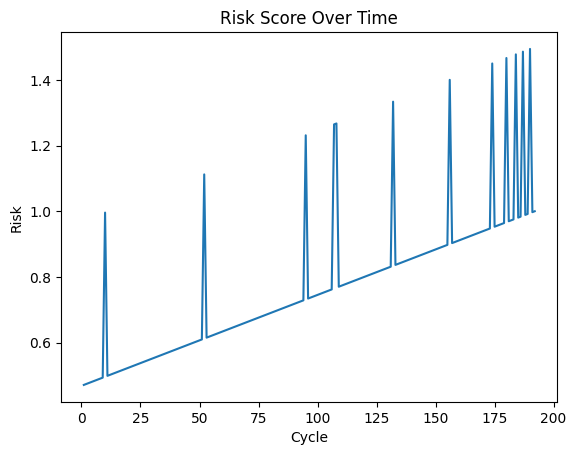

In [37]:
import matplotlib.pyplot as plt

unit_id = 1
unit_df = train[train['unit'] == unit_id]

plt.plot(unit_df['cycle'], unit_df['risk_score'])
plt.title("Risk Score Over Time")
plt.xlabel("Cycle")
plt.ylabel("Risk")
plt.show()

####Phase 04 - Visualization and Deployment

Save final data

In [38]:
train.to_csv("final_spacecraft_data.csv", index=False)

In [39]:
from google.colab import files
files.download("final_spacecraft_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Interactive Dashboard in Colab

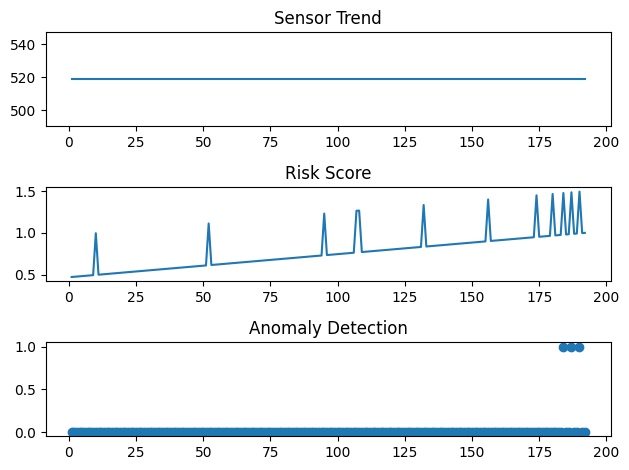

In [41]:
unit_id = 1
unit_df = train[train['unit'] == unit_id]

plt.subplot(3,1,1)
plt.plot(unit_df['cycle'], unit_df['s1'])
plt.title("Sensor Trend")

plt.subplot(3,1,2)
plt.plot(unit_df['cycle'], unit_df['risk_score'])
plt.title("Risk Score")

plt.subplot(3,1,3)
plt.scatter(unit_df['cycle'], unit_df['ml_anomaly'])
plt.title("Anomaly Detection")

plt.tight_layout()
plt.show()

Real-time alert system

In [42]:
import time

print("🚀 Starting Real-Time Monitoring...\n")

for i in range(50):
    row = train.iloc[i]

    if row['alert'] == "ALERT_GROUND_STATION":
        print(f"🚨 ALERT at Cycle {row['cycle']} | Risk: {row['risk_level']} | Action: {row['action']}")
    else:
        print(f"✅ Cycle {row['cycle']} Normal")

    time.sleep(0.1)

🚀 Starting Real-Time Monitoring...

✅ Cycle 1 Normal
✅ Cycle 2 Normal
✅ Cycle 3 Normal
✅ Cycle 4 Normal
✅ Cycle 5 Normal
✅ Cycle 6 Normal
✅ Cycle 7 Normal
✅ Cycle 8 Normal
✅ Cycle 9 Normal
✅ Cycle 10 Normal
✅ Cycle 11 Normal
✅ Cycle 12 Normal
✅ Cycle 13 Normal
✅ Cycle 14 Normal
✅ Cycle 15 Normal
✅ Cycle 16 Normal
✅ Cycle 17 Normal
✅ Cycle 18 Normal
✅ Cycle 19 Normal
✅ Cycle 20 Normal
✅ Cycle 21 Normal
✅ Cycle 22 Normal
✅ Cycle 23 Normal
✅ Cycle 24 Normal
✅ Cycle 25 Normal
✅ Cycle 26 Normal
✅ Cycle 27 Normal
✅ Cycle 28 Normal
✅ Cycle 29 Normal
✅ Cycle 30 Normal
✅ Cycle 31 Normal
✅ Cycle 32 Normal
✅ Cycle 33 Normal
✅ Cycle 34 Normal
✅ Cycle 35 Normal
✅ Cycle 36 Normal
✅ Cycle 37 Normal
✅ Cycle 38 Normal
✅ Cycle 39 Normal
✅ Cycle 40 Normal
✅ Cycle 41 Normal
✅ Cycle 42 Normal
✅ Cycle 43 Normal
✅ Cycle 44 Normal
✅ Cycle 45 Normal
✅ Cycle 46 Normal
✅ Cycle 47 Normal
✅ Cycle 48 Normal
✅ Cycle 49 Normal
✅ Cycle 50 Normal


Final system integration

In [43]:
def spacecraft_monitoring_system(data):

    results = []

    for _, row in data.iterrows():

        output = {
            "cycle": row['cycle'],
            "anomaly": row['ml_anomaly'],
            "decision": row['decision_rule'],
            "action": row['action'],
            "risk": row['risk_level'],
            "confidence": row['confidence']
        }

        results.append(output)

    return results

final_output = spacecraft_monitoring_system(train)

print("Sample Output:")
print(final_output[:5])

Sample Output:
[{'cycle': 1, 'anomaly': 0, 'decision': 'NORMAL', 'action': 'NORMAL_OPERATION', 'risk': 'LOW', 'confidence': 100}, {'cycle': 2, 'anomaly': 0, 'decision': 'NORMAL', 'action': 'NORMAL_OPERATION', 'risk': 'LOW', 'confidence': 100}, {'cycle': 3, 'anomaly': 0, 'decision': 'NORMAL', 'action': 'NORMAL_OPERATION', 'risk': 'LOW', 'confidence': 100}, {'cycle': 4, 'anomaly': 0, 'decision': 'NORMAL', 'action': 'NORMAL_OPERATION', 'risk': 'LOW', 'confidence': 100}, {'cycle': 5, 'anomaly': 0, 'decision': 'NORMAL', 'action': 'NORMAL_OPERATION', 'risk': 'LOW', 'confidence': 100}]


Final output summary

In [44]:
print("Total Data Points:", len(train))
print("Total Anomalies:", train['ml_anomaly'].sum())
print("High Risk Cases:", (train['risk_level'] == "HIGH").sum())

Total Data Points: 20631
Total Anomalies: 413
High Risk Cases: 918


In [45]:
train.to_csv("final_output.csv", index=False)

Confusion Matrix

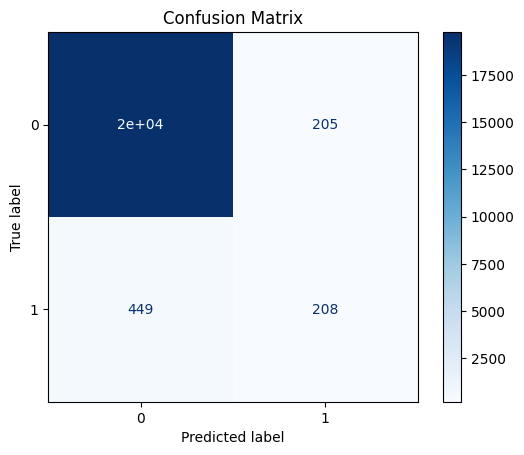

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(train['stat_anomaly'], train['ml_anomaly'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()